In [ ]:
%pip install -q pandas numpy matplotlib scipy pyyaml ipywidgets

Note: you may need to restart the kernel to use updated packages.


# Downstream Evaluation: RankMe Geometry → Multilingual Performance

**Research question:** *Do spectral geometry features of the RankMe training trajectory predict downstream multilingual performance? Specifically: do per-language richness levels and the live geometry-performance alignment correlate with accuracy and grokking behaviour on m-MMLU, XCOPA, Belebele, and M-ARC?*

**Models:** FuxiTranyu-8B · Apertus-8B-2509  
**Benchmarks:** m-MMLU (5-shot, 8 languages) · XCOPA (0-shot, 5 languages) · Belebele (5-shot, 10 languages) · M-ARC (5-shot, 9 languages) — configured in `code/downstream_evaluation/configs/benchmarks.yaml`  
**Geometry source:** `fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`

### What this notebook does

1. **Layer selection** —cross-language stratification analysis to justify which layer's RankMe values are used throughout: layer 21 for FuxiTranyu-8B and layer 19 for Apertus-8B-2509 (layers of maximum cross-language RankMe spread over the first 10 training checkpoints).

2. **RankMe trajectory analysis** — for each language, computes key geometry metrics from the training trajectory at the selected layer: global peak, trajectory-averaged richness over non-overlapping quartile windows, and early-training richness at checkpoint 10.

3. **Grokking detection** — finds the first checkpoint where accuracy exceeds random chance by more than 15 percentage points and stays there for at least 2 consecutive checkpoints. Separately per task and language.

4. **Overlay plots** — dual-axis plots overlaying the RankMe trajectory and accuracy curve per language, with grokking onset marked. One plot per task (m-MMLU, XCOPA, Belebele, M-ARC).

5. **Predictor correlation analysis** — tests seven RankMe richness predictors (point-in-time richness and non-overlapping quartile means) against two outcomes (grokking onset, peak accuracy) using Spearman and Pearson correlations. Grokking onset uses only RankMe at first checkpoint (at or before grokking onset); peak accuracy uses all seven predictors. Computed separately per task, never pooled across tasks.

6. **Per-checkpoint cross-language correlation** — at every training checkpoint, computes the Spearman rank correlation between RankMe and accuracy *across languages*, yielding a trajectory that shows when and how strongly the geometry tracks the live language performance hierarchy.

In [ ]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, clear_output

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(REPO_ROOT, "code", "downstream_evaluation"))

from utils import (
    load_config, init_models,
    load_rankme_data, load_eval_data, load_model_data,
    compute_geometry, compute_and_show_geometry,
    compute_grokking, compute_and_show_grokking,
    compute_correlations_table, compute_and_show_correlations,
    compute_checkpoint_correlations, compute_and_show_checkpoint_correlations,
    show_stratification, layer_selection_sweep,
    plot_rankme_phases, show_rankme_phases,
    plot_predictor_scatter, show_predictor_scatter,
    plot_correlation_heatmap, show_correlation_heatmap,
    plot_checkpoint_correlations, show_checkpoint_correlations,
    show_overlay_widget,
)

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


## Configuration

The notebook analyses **both models simultaneously**. `init_models()` loads config, colors, and benchmark metadata from `configs/benchmarks.yaml` for each model.

In [ ]:
MODELS, data = init_models()

[fuxi] FuxiTranyu-8B  |  Layer: layer_21  |  Aggregation: last
[apertus] Apertus-8B-2509  |  Layer: layer_19  |  Aggregation: last


## Layer Selection

RankMe is computed at every layer and checkpoint, but the correlation and per-checkpoint analyses require choosing one representative layer per model.

To select the most informative layer, we measure the **cross-language stratification signal** at each layer: for each language we average RankMe across the **first 10 training checkpoints**, then compute the standard deviation of those per-language averages across languages. Using a small number of checkpoints reflects the target use-case of this study: we want to draw conclusions about the final multilingual performance of a model while still in the early stages of training. At that point, only a limited number of checkpoints are available, and the goal is to use the geometry metrics computed from those checkpoints to predict final outcomes. In this study we use N=10, corresponding to ~17% of total training for FuxiTranyu-8B and ~22% for Apertus-8B-2509.

**A high standard deviation means the layer separates languages strongly** — it encodes language-specific geometry rather than universal features shared by all languages. This is the layer with the most signal for predicting per-language downstream outcomes.

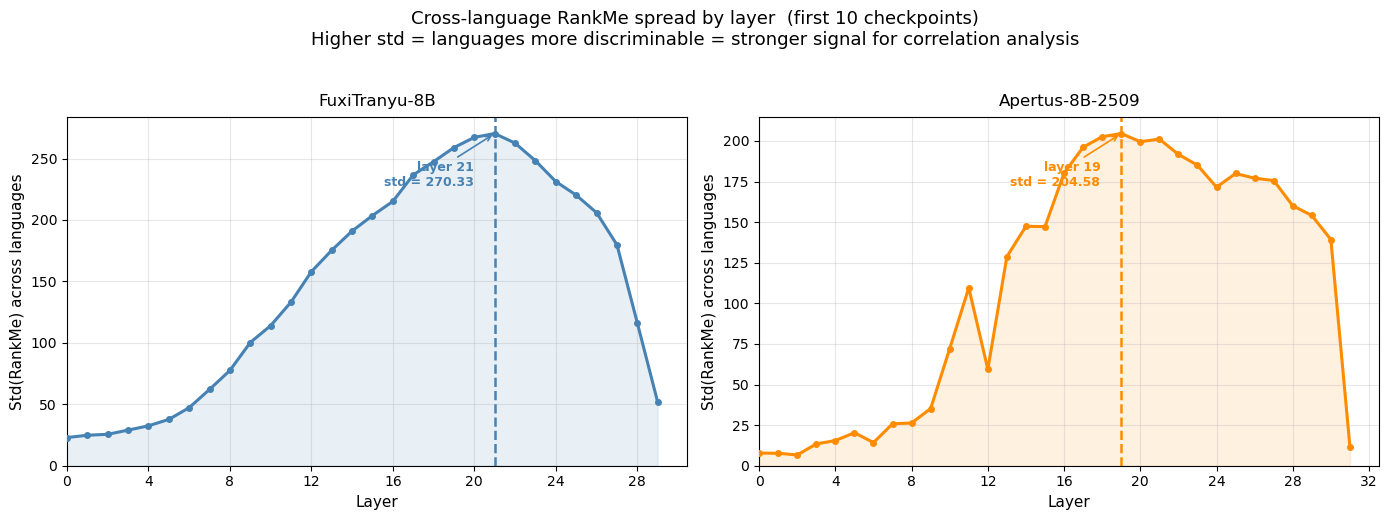

Saved: plots_joao_pinto_407597/rankme_layer_stratification.png


In [ ]:
show_stratification(MODELS, data, n_first_checkpoints=10)

### Selected layers

- **FuxiTranyu-8B → layer 21**: the layer with the strongest cross-language RankMe spread over the first 10 checkpoints, located in the upper-middle part of the network.
- **Apertus-8B-2509 → layer 19**: the layer with the strongest cross-language RankMe spread over the first 10 checkpoints, located in the middle part of the network.

These are the layers used throughout this notebook for all correlation and per-checkpoint analyses.

## Data

Two sources are loaded:

- **`fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`** — geometry metrics for all checkpoints, all languages, and all layers. Used for layer selection, trajectory plots, and per-checkpoint correlation.

- **`fuxi_fine_wiki_mmlu_xcopa_belebele_marc_layer15_merged.csv` / `apertus_fine_wiki_mmlu_xcopa_belebele_marc_layer21_merged.csv`** — downstream accuracy for all four benchmarks merged with geometry at the selected layer. Used for grokking detection, correlation analysis, and overlay plots.

In [ ]:
load_model_data(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
Loaded geometry data: 47,880 rows — 57 checkpoints, 14 languages
Working slice : layer_21, agg=last → 798 rows
Loaded eval: 1824 records — 4 task(s), 57 checkpoint(s)

── Apertus-8B-2509 ────────────────────────────────────────
Loaded geometry data: 39,424 rows — 44 checkpoints, 14 languages
Working slice : layer_19, agg=last → 616 rows
Loaded eval: 1408 records — 4 task(s), 44 checkpoint(s)


## RankMe Trajectories

The table below summarises key geometry metrics per language, derived from the RankMe trajectory at the working layer:

- **tokens at peak (B)** — training token count at the global RankMe maximum.
- **RankMe at peak** — RankMe value at the global maximum.
- **RankMe first checkpoint** — representational richness at the first observed checkpoint.
- **RankMe checkpoint 10** — representational richness at the 10th checkpoint.
- **mean first 10 checkpoints** — mean RankMe over the first 10 checkpoints.
- **mean Q2 (25–50%)** — mean RankMe over checkpoints in the second quartile of the token range.
- **mean Q3 (50–75%)** — mean RankMe over checkpoints in the third quartile of the token range.
- **mean Q4 (75–100%)** — mean RankMe over checkpoints in the last quartile of the token range.
- **RankMe last checkpoint** — representational richness at the end of training.

In [ ]:
compute_and_show_geometry(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
  language  tokens at peak (B)  RankMe at peak  RankMe first checkpoint  RankMe checkpoint 10  mean first 10 checkpoints  mean Q2 (25–50%)  mean Q3 (50–75%)  mean Q4 (75–100%)  RankMe last checkpoint
    Arabic                10.0        248.9590                 248.9590              175.9130                  184.82829         89.982407         50.425064          27.976340                 22.4071
   Chinese                10.0        476.4899                 476.4899              379.8995                  408.35974        126.730493         37.610671          22.702660                 19.7860
   English                52.0        836.4859                 755.8186              678.6350                  710.22234        153.694193         40.678300          16.104553                 11.0804
   Finnish                52.0        648.6929                 541.5157              588.5595                  547.35822        221.582493   

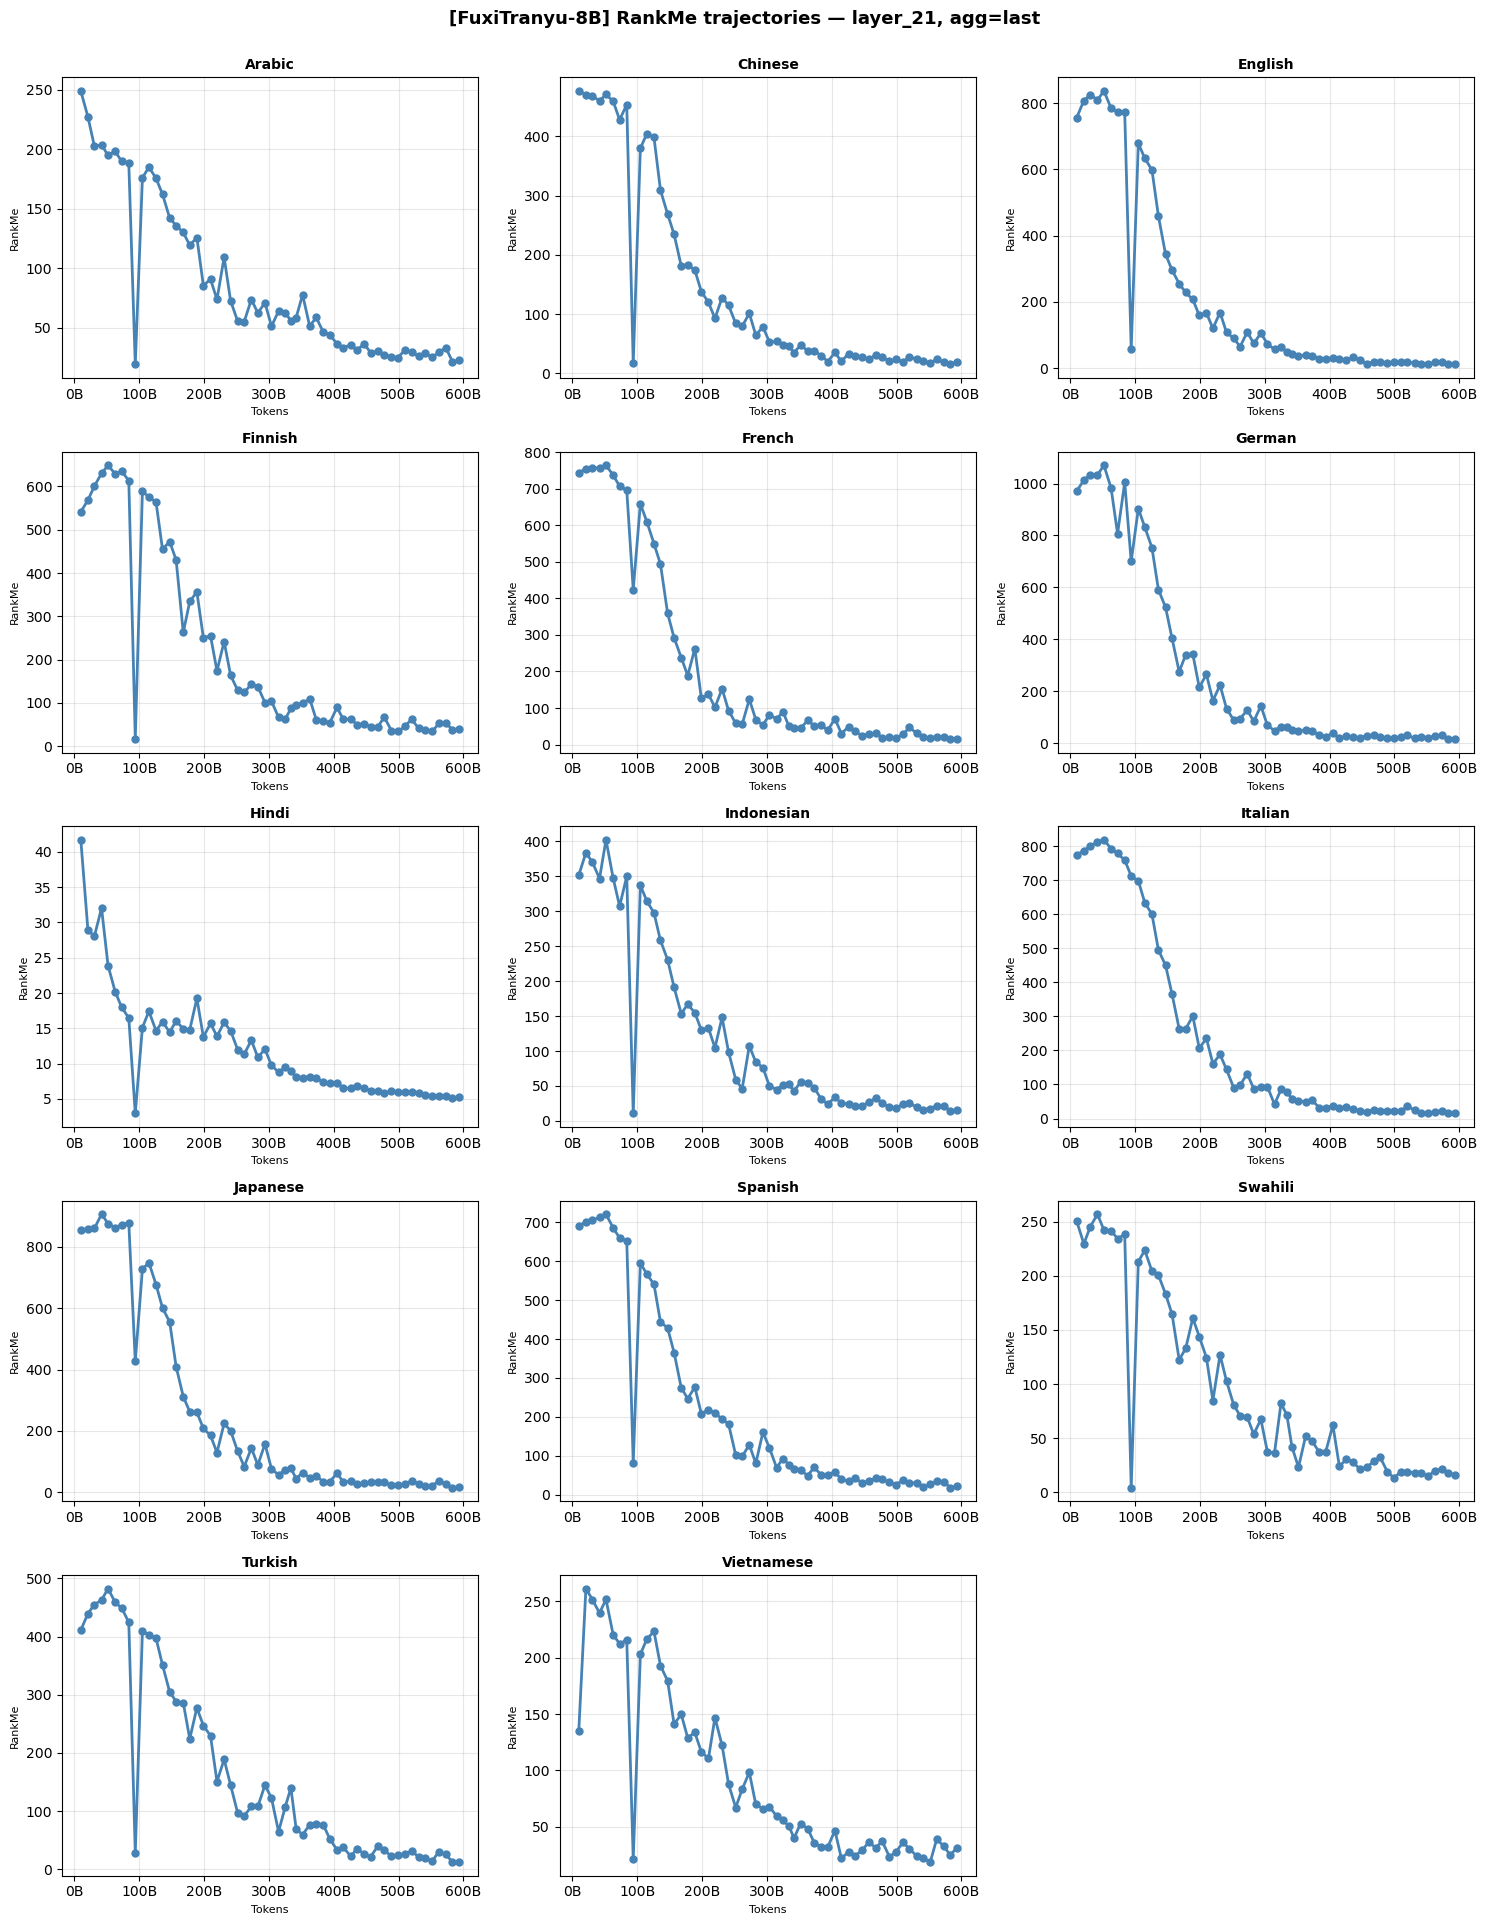

Saved: plots_joao_pinto_407597/rankme_phases_fuxi.png


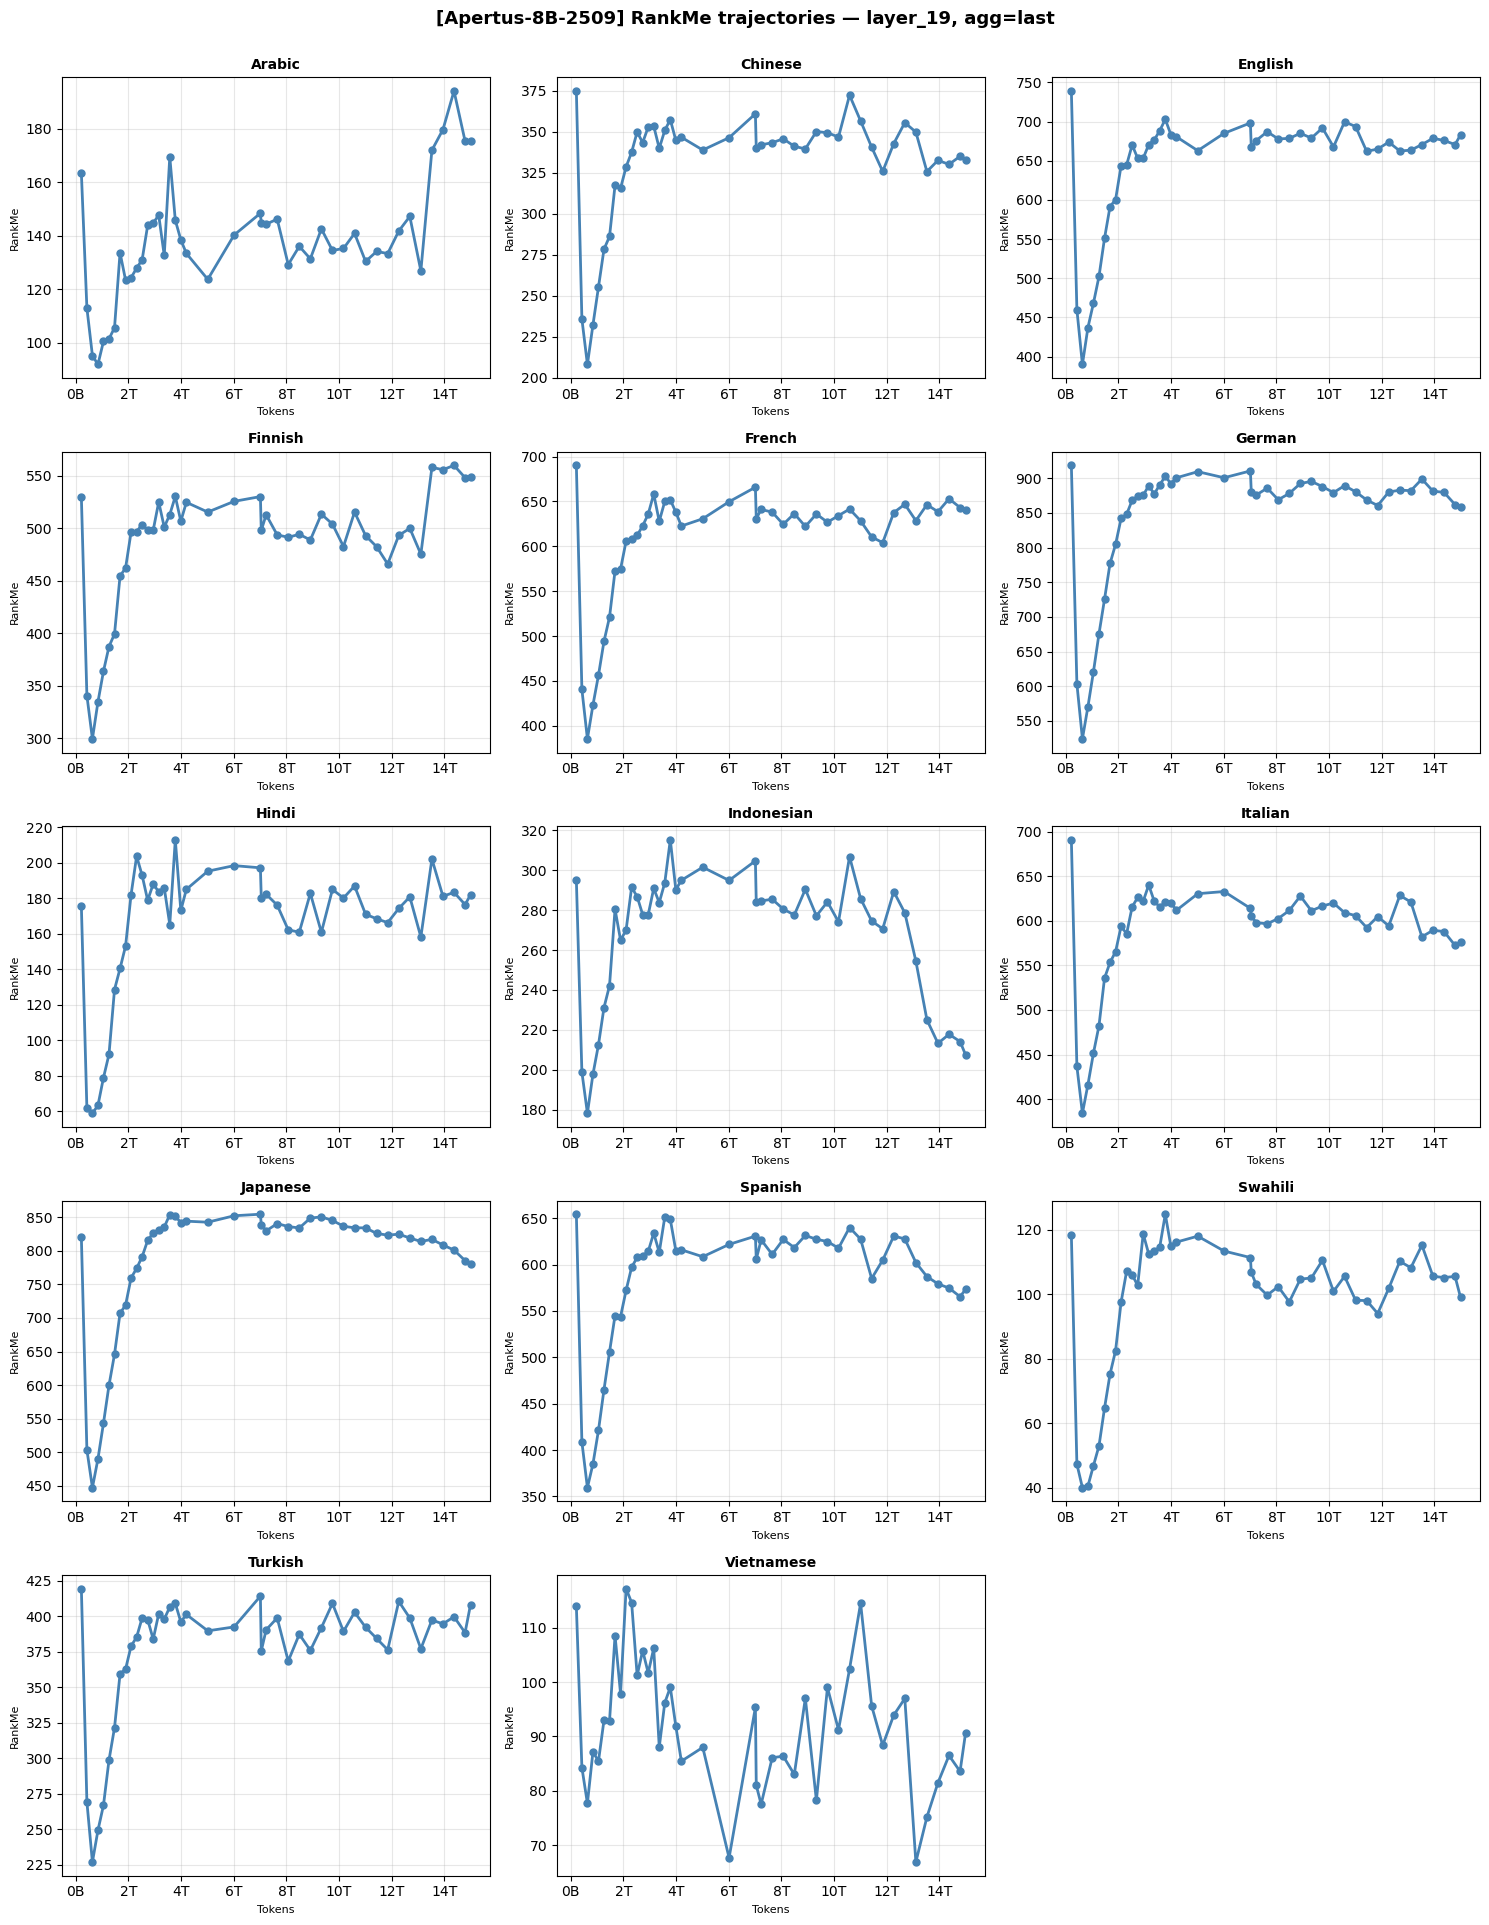

Saved: plots_joao_pinto_407597/rankme_phases_apertus.png


In [ ]:
show_rankme_phases(MODELS, data)

## Grokking Detection

For each (task, language) pair, the table below reports when the model transitions from near-random guessing to genuinely solving the task. Grokking onset and peak accuracy serve as the outcome variables for the RankMe correlation analysis.

- **grokking onset (B)** — training token count (in billions) at the first checkpoint where accuracy exceeds the random chance baseline by more than 15 percentage points and stays there for at least 2 consecutive checkpoints.
- **tokens at peak accuracy (B)** — training token count at the checkpoint with the highest observed accuracy.
- **peak accuracy** — highest accuracy observed across all checkpoints.
- **random chance baseline** — expected accuracy for a random classifier (0.25 for 4-way tasks: m-MMLU, Belebele, and M-ARC; 0.50 for 2-way XCOPA).

A `NaN` grokking onset means one of two things: either the model never exceeded the threshold at any checkpoint (accuracy stays near random chance throughout), or the threshold was crossed only once without the required 2 consecutive checkpoints.

In [ ]:
compute_and_show_grokking(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
    task   language  grokking onset (B)  tokens at peak accuracy (B)  peak accuracy  random chance baseline
  m_mmlu    English                 NaN                        115.0       0.272590                    0.25
  m_mmlu    Chinese                 NaN                        334.0       0.272921                    0.25
  m_mmlu     German                 NaN                        199.0       0.274928                    0.25
  m_mmlu    Spanish                 NaN                        241.0       0.276211                    0.25
  m_mmlu    Italian                 NaN                        415.0       0.275818                    0.25
  m_mmlu     Arabic                 NaN                        531.0       0.273824                    0.25
  m_mmlu      Hindi                 NaN                        210.0       0.269438                    0.25
  m_mmlu Indonesian                 NaN                        115.0       0.

## Overlay Plots

One plot per selected task, with one panel per language. Each panel shows two y-axes:

- **Left axis** — RankMe trajectory across training checkpoints.
- **Right axis (red, dashed)** — downstream accuracy across all checkpoints. The axis always spans 0 to 1.

The black dashed horizontal line marks the random-chance baseline (0.25 for m-MMLU / Belebele / M-ARC, 0.50 for XCOPA). A vertical purple dashed line marks the grokking onset for that language — absent when grokking was not detected.

> **Note:** M-MMLU is selected by default for reading purposes. Use the checkboxes to choose any combination of tasks (M-MMLU, XCOPA, Belebele, M-ARC) per model, then click **Generate plots** to update. Rendering takes approximately 2 seconds per task per model.

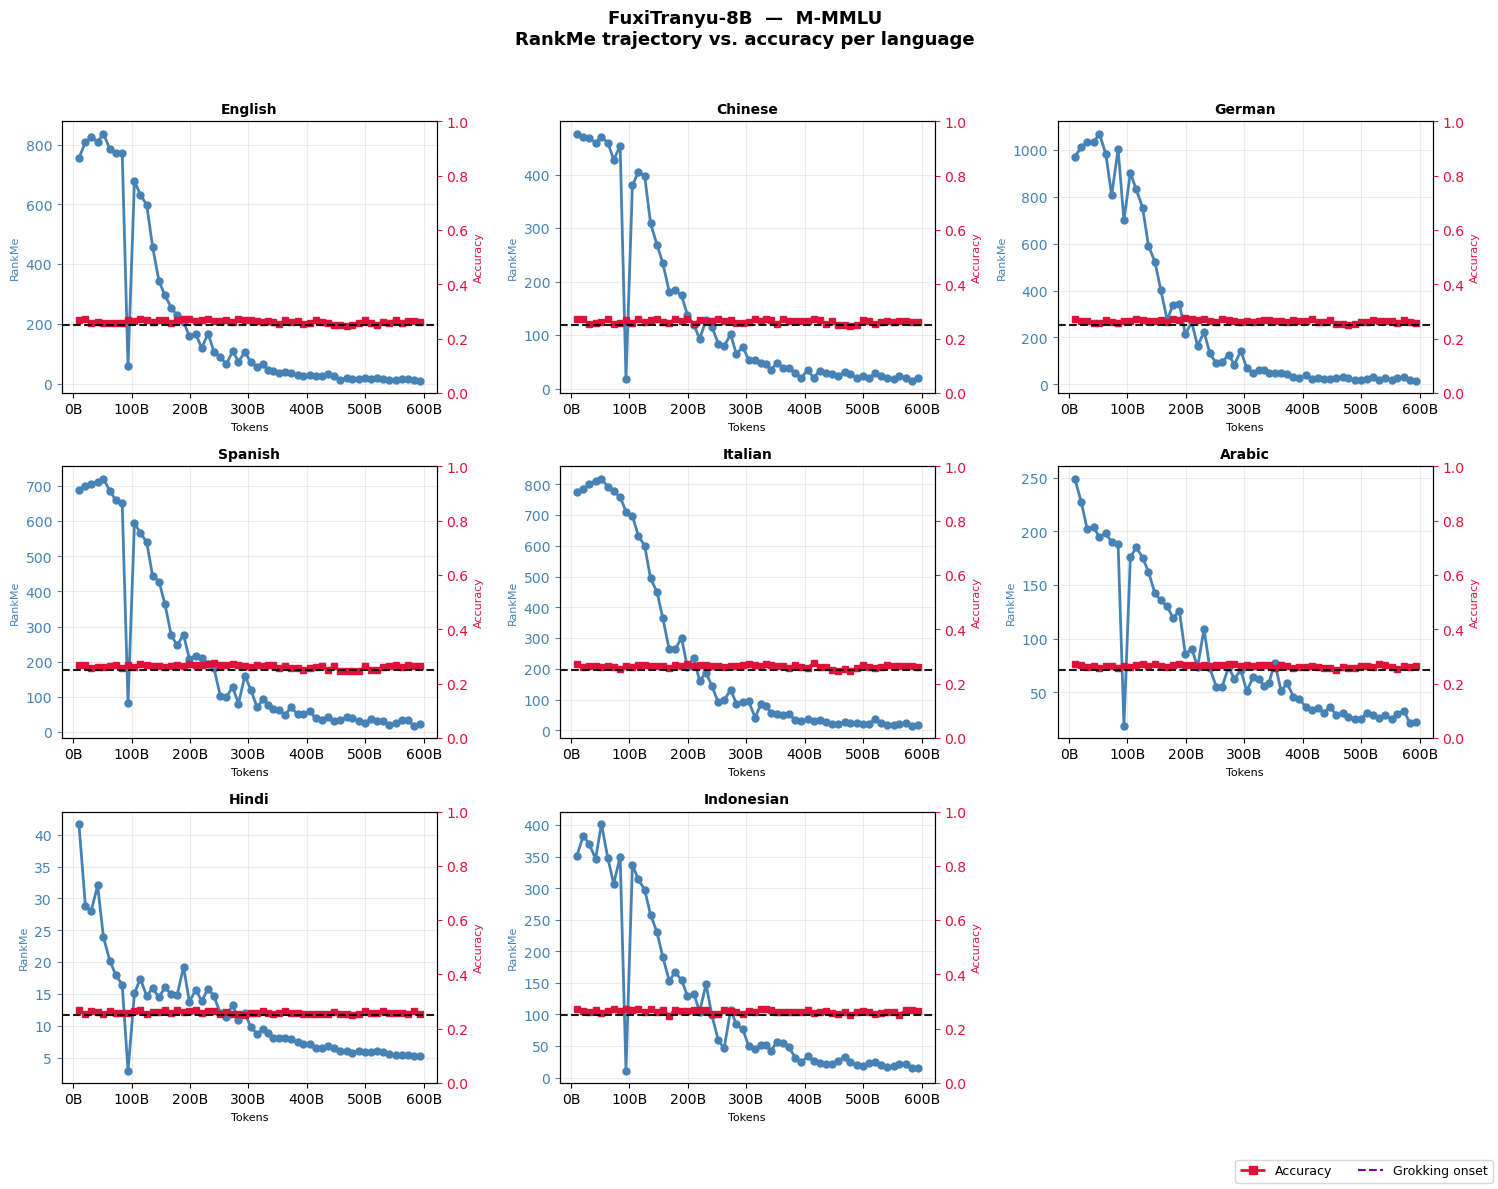

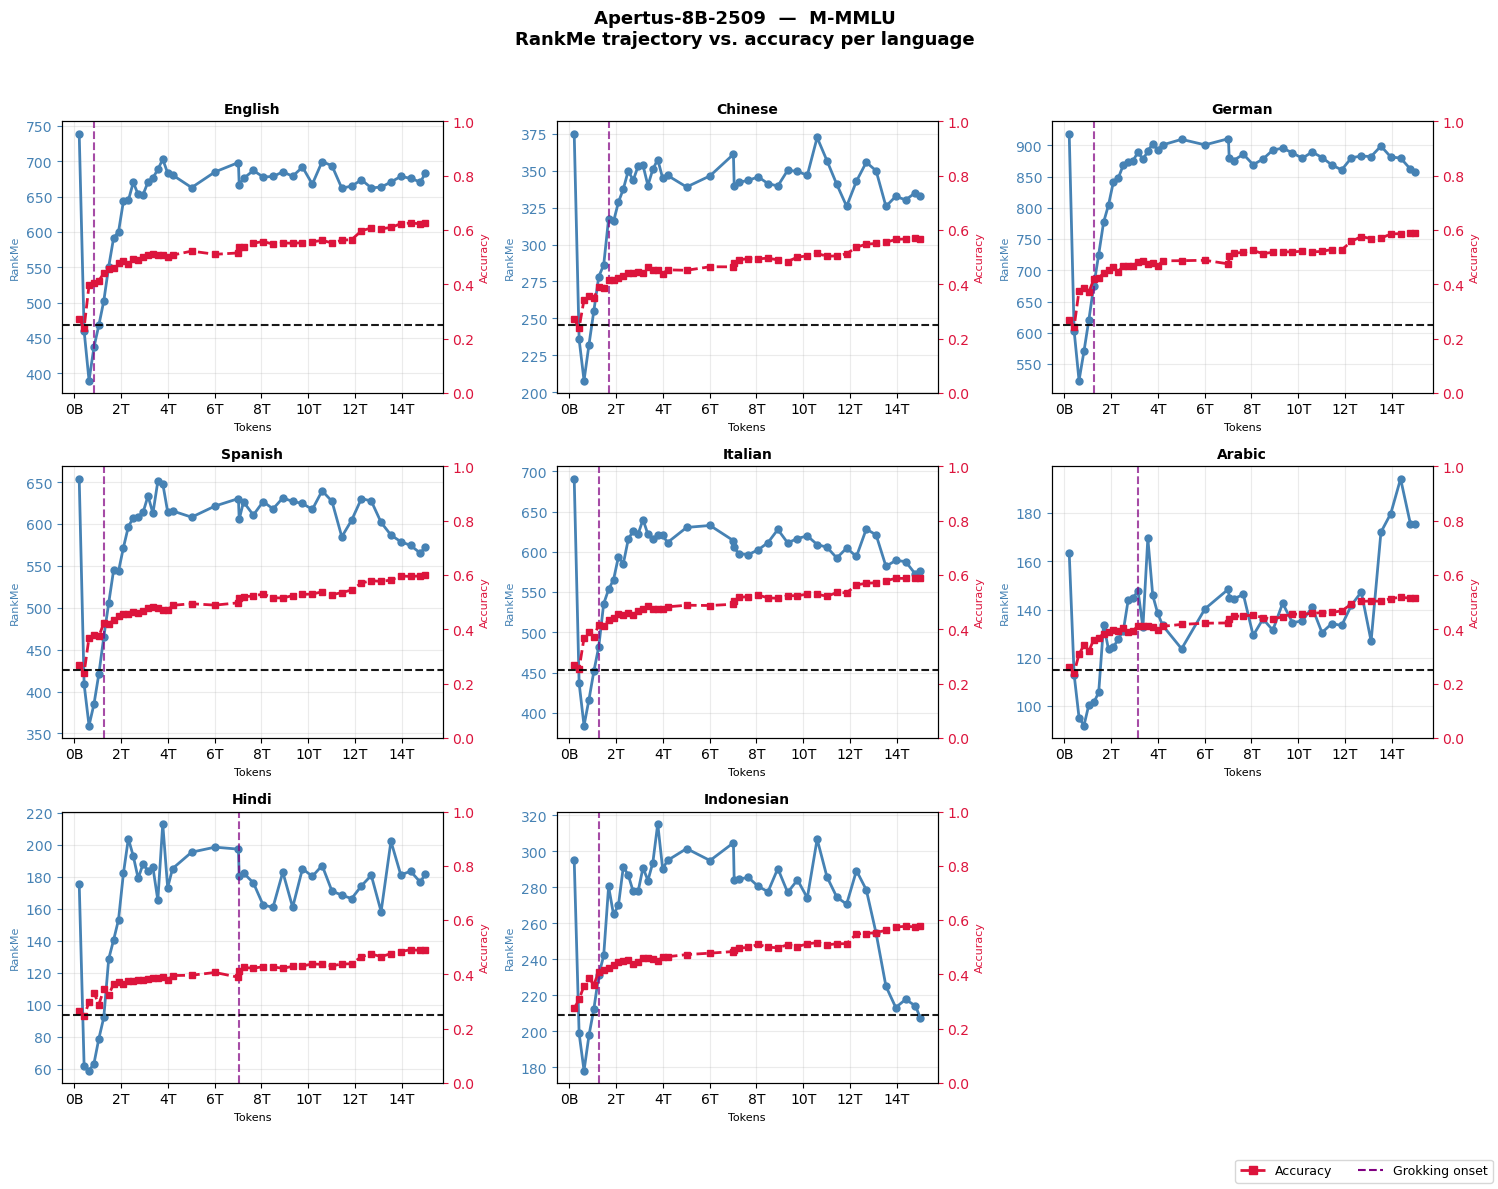

In [ ]:
show_overlay_widget(MODELS, data)

## Geometry–Performance Correlation: Do RankMe trajectory features predict grokking onset and peak accuracy?

Tests whether RankMe geometry predicts downstream performance. The predictor set depends on the outcome:

**Grokking onset** uses only **RankMe at first checkpoint** — the single checkpoint at or before grokking onset in every (model, task, language) combination. Using later trajectory data would risk incorporating post-grokking information.

**Peak accuracy** uses all **seven richness predictors** (retrospective — no leakage risk):
- **RankMe at first checkpoint** — representation richness at the start of training.
- **RankMe at checkpoint 10** — representation richness at the 10th checkpoint (the layer-selection horizon).
- **Mean RankMe — first 10 checkpoints** — average over the first 10 checkpoints (the layer-selection window).
- **Mean RankMe — Q2 (25–50%)** — average over checkpoints in the second quartile of the token range.
- **Mean RankMe — Q3 (50–75%)** — average over checkpoints in the third quartile of the token range.
- **Mean RankMe — Q4 (75–100%)** — average over checkpoints in the last quartile of the token range.
- **RankMe at last checkpoint** — representation richness at the end of training.

Both Spearman (rank-based) and Pearson (linear) correlations are reported, computed separately per task and never pooled.

In [ ]:
compute_and_show_correlations(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
    task                      predictor (x)        outcome (y)  n_languages  spearman_r  spearman_p  pearson_r  pearson_p
  m_mmlu         RankMe at first checkpoint Grokking onset (B)            0         NaN         NaN        NaN        NaN
  m_mmlu         RankMe at first checkpoint      Peak accuracy            8      0.5238      0.1827     0.7249     0.0419
  m_mmlu            RankMe at checkpoint 10      Peak accuracy            8      0.5238      0.1827     0.7034     0.0516
  m_mmlu Mean RankMe — first 10 checkpoints      Peak accuracy            8      0.5238      0.1827     0.7056     0.0505
  m_mmlu          Mean RankMe — Q2 (25–50%)      Peak accuracy            8      0.6905      0.0580     0.8850     0.0035
  m_mmlu          Mean RankMe — Q3 (50–75%)      Peak accuracy            8      0.9048      0.0020     0.9303     0.0008
  m_mmlu         Mean RankMe — Q4 (75–100%)      Peak accuracy            8      0.7857

### Correlation Heatmap

The table above has rows for each (task × outcome × predictor) combination. The heatmap below condenses all of them into a single 7×8 figure per model (rows = all 7 richness predictors, columns = tasks × outcomes). Colour encodes Spearman ρ; * marks p < 0.05. Gray cells indicate undefined correlations (zero variance in the predictor) or predictors not used for that outcome — grokking onset only uses RankMe at first checkpoint, so the remaining 6 predictor rows are gray in all grokking onset columns.

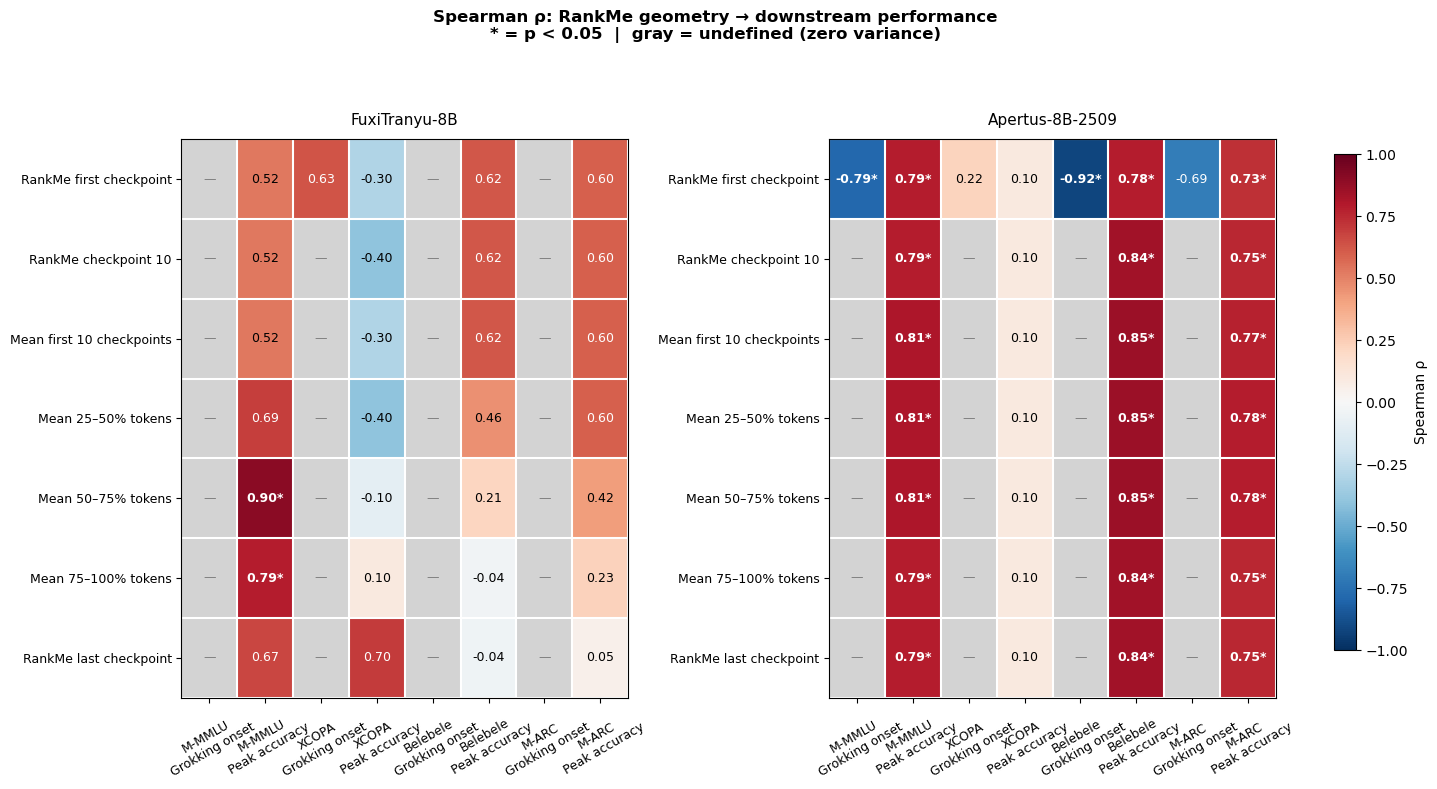

Saved: plots_joao_pinto_407597/correlation_heatmap.png


In [ ]:
show_correlation_heatmap(MODELS, data)

### Selected Scatter Plot

**RankMe at first checkpoint** is highlighted as the single most interpretable predictor: it requires only one forward pass at the very first checkpoint — no trajectory averaging — yet it is the only predictor used for grokking onset and among the strongest for peak accuracy across all tasks for Apertus. The figure shows one row per task (m-MMLU, XCOPA, Belebele, M-ARC) against both outcomes, with per-model regression lines and Spearman/Pearson statistics.

> **What to look for:** For Apertus, a consistent pattern is visible for m-MMLU, Belebele, and M-ARC — richer representations at the first checkpoint correlate with earlier grokking onset and higher peak accuracy. XCOPA is the exception: all 5 languages score between 0.702 and 0.784, so outcomes are too tightly clustered for representational richness to differentiate them. For Fuxi, m-MMLU and Belebele stay at random chance throughout training, leaving no signal. Only M-ARC shows a meaningful correlation (Pearson r = +0.816, p = 0.007).

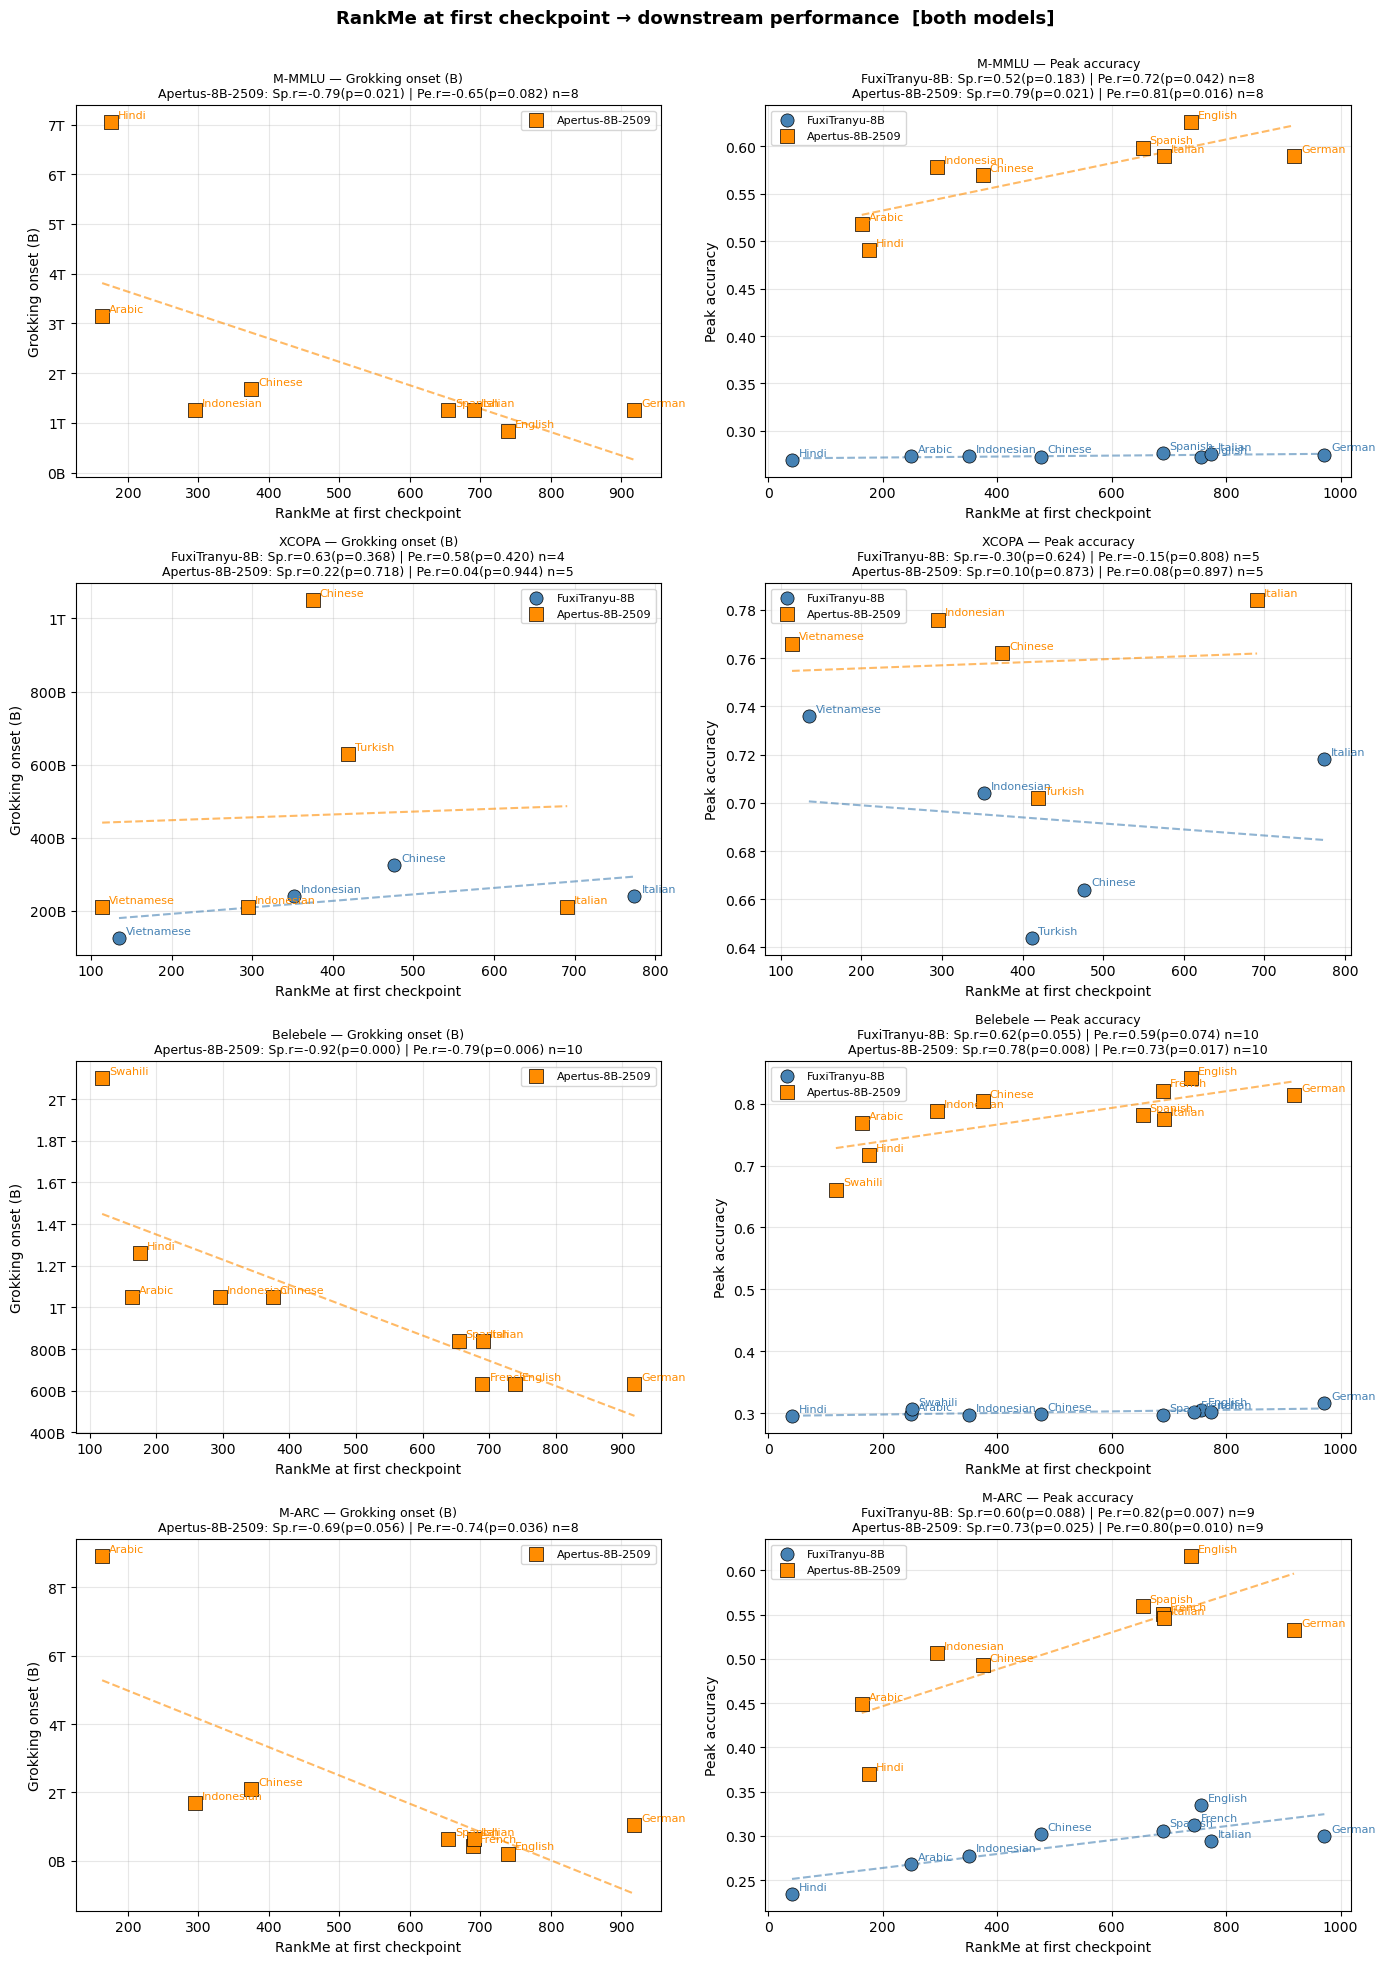

Saved: plots_joao_pinto_407597/scatter_rankme_first.png


In [ ]:
show_predictor_scatter(MODELS, data, "rankme_first", "RankMe at first checkpoint")

## Predictor Analysis Findings

### FuxiTranyu-8B

**Representational richness** — Layer 21 (std = 270.3 at N=10): peak RankMe spans over an order of magnitude, from German (1070) and Japanese (905) down to Hindi (42). 8 of 14 languages peak at 52B tokens; Arabic, Chinese, and Hindi at 10B; Vietnamese at 21B; Japanese and Swahili at 42B.

**m-MMLU** — Accuracy stays at random chance (~25%) across all 57 checkpoints for all 8 languages. No grokking detected. The accuracy range is only 0.007 (0.269–0.276), entirely within sampling noise. The late-training windows nominally reach Spearman significance — Q3 (Sp r = +0.905, p = 0.002) and Q4 (Sp r = +0.786, p = 0.021) — but this is almost certainly spurious: a 0.007 accuracy spread is insufficient for reliable inference regardless of the ρ value. No early predictor (first checkpoint, checkpoint 10, mean first 10) reaches significance by Spearman; RankMe at last checkpoint also does not (Sp r = +0.667, p = 0.071).

**XCOPA** — 4 of 5 languages grokked: Vietnamese (126B), Italian and Indonesian (241B), Chinese (325B); Turkish never crossed the threshold. Grokking onset (RankMe at first checkpoint only, n=4): Sp r = +0.633, p = 0.368 — not significant; with n=4 the minimum exact two-tailed Spearman p-value is ≈ 0.083, so significance is structurally impossible. **No predictor reaches significance for peak accuracy** (all p > 0.18); the closest is RankMe at last checkpoint (Sp r = +0.700, p = 0.188).

**Belebele** — All 10 languages stay near random chance (peak accuracy 0.296–0.317). No grokking detected. No significant predictors. The three early-training predictors (RankMe at first checkpoint, checkpoint 10, and mean first 10 checkpoints) all produce the same Spearman correlation of ρ = +0.622 (p = 0.055) — they yield the same language rank ordering and are therefore equivalent in this case. This is close to the 0.05 significance threshold but does not reach it. Q2, Q3, Q4, and last checkpoint are weaker and also not significant.

**M-ARC** — No grokking; peak accuracy spans 0.235 (Hindi) to 0.335 (English). **Early-training richness predicts peak accuracy by Pearson but not Spearman**: RankMe at first checkpoint (Pe r = +0.816, p = 0.007), checkpoint 10 (Pe r = +0.792, p = 0.011), mean first 10 (Pe r = +0.782, p = 0.013), Q2 (Pe r = +0.756, p = 0.018). Q3, Q4, and last checkpoint are not significant. Spearman is not significant for any predictor. Languages with richer representations in the first half of training achieve higher M-ARC accuracy; late-training richness (Q4, last checkpoint) carries no signal.

---

### Apertus-8B-2509

**Representational richness** — Layer 19 (std = 204.6 at N=10): peak RankMe ranges from German (919) and Japanese (854) down to Swahili (125) and Vietnamese (117). 7 languages (Chinese, English, French, German, Italian, Spanish, Turkish) peak at 210B; 3 (Hindi, Indonesian, Swahili) at 3 780B; Vietnamese at 2 100B; Japanese at 7 014B; Arabic and Finnish continue growing throughout training, peaking at 14 372B.

**m-MMLU** — All 8 languages grokked (840B–7 047B). Grokking onset (RankMe at first checkpoint only): **Sp r = −0.786, p = 0.021** — richer representations at the first checkpoint → earlier grokking. Pearson is not significant (p = 0.083), indicating a rank-monotone but non-linear relationship. Peak accuracy: **all 7 richness predictors are significant (Sp r = +0.786–0.810, all p ≤ 0.021)**. Mean first 10 checkpoints, Q2, and Q3 are the joint strongest (Sp r = +0.810, p = 0.015 each).

**XCOPA** — All 5 languages grokked (210B–1 050B). Grokking onset (RankMe at first checkpoint): Sp r = +0.224, p = 0.718 — not significant. Peak accuracy: **no predictor is significant** (all Sp r = +0.100, all p > 0.87). XCOPA outcomes are tightly clustered (0.702–0.784) and established very early in training, leaving no cross-language variance for richness to predict.

**Belebele** — All 10 languages grokked (630B–2 100B). **Strongest geometry–performance relationship in the analysis:** grokking onset: **Sp r = −0.916, p < 0.001**; peak accuracy: **all 7 predictors significant (Sp r = +0.782–0.855, all p ≤ 0.008)**. Mean first 10 checkpoints, Q2, and Q3 are the joint strongest predictors (Sp r = +0.855, p = 0.002 each).

**M-ARC** — 8 of 9 languages grokked (210B–8 912B; Hindi did not). Grokking onset (n=8): Sp r = −0.695, p = 0.056 — marginal by Spearman; **Pe r = −0.739, p = 0.036** — significant by Pearson. Peak accuracy: **all 7 predictors significant (Sp r = +0.733–0.783, all p ≤ 0.025)**. Q2 and Q3 are the joint strongest (Sp r = +0.783, p = 0.013 each).

---

### Cross-model summary

**The only finding that replicates across both models with the same direction is early-training RankMe richness → M-ARC peak accuracy:**
- FuxiTranyu-8B: first checkpoint, checkpoint 10, mean first 10, and Q2 all significant by Pearson (Pe r = +0.816 / +0.792 / +0.782 / +0.756, p = 0.007 / 0.011 / 0.013 / 0.018); Spearman not significant for any predictor; late-training predictors (Q3, Q4, last checkpoint) carry no signal
- Apertus-8B-2509: all 7 predictors significant by Spearman (Sp r = +0.733–0.783).

All other cross-model comparisons fail because Fuxi never learns most benchmarks during pre-training: m-MMLU and Belebele accuracy stays at random chance (no variance, no valid correlations), and XCOPA grokking onset has only n=4 events (underpowered). The richness-predictor findings for Apertus (m-MMLU, Belebele, M-ARC) have no Fuxi counterpart — except M-ARC.

---
### 💡 Key findings

- **Apertus — m-MMLU, Belebele, M-ARC:** All 7 predictors significant; RankMe at first checkpoint negatively correlates with grokking onset (richer → earlier grokking) and positively with peak accuracy (richer → higher accuracy).
- **Apertus — XCOPA:** no predictor reaches significance for any outcome — XCOPA outcomes are too tightly clustered for representational richness to differentiate languages.
- **Fuxi — M-ARC:** early-training richness (first checkpoint through Q2) predicts peak accuracy by Pearson (Pe r ≈ +0.76–0.82); Q3, Q4, and last checkpoint lose significance.
- **Both models — M-ARC:** the only cross-model replication — richer representations in the first half of training predict science reasoning accuracy in both models.

## Per-Checkpoint Correlation: Does geometry track the language performance hierarchy over training?

The previous predictor analysis tested whether a single geometry metric (computed from the full RankMe trajectory) predicts a language's final downstream outcome. Here we ask a complementary question: **at each training checkpoint, does the cross-language ranking of RankMe match the cross-language ranking of accuracy at that same checkpoint?**

At any given checkpoint (say, 3 360B tokens), we have two values per language — RankMe and accuracy on a given task — and we compute **one Spearman correlation** across all languages. For example, for Apertus at 3 360B on m-MMLU, sorted by RankMe:

| Language   | RankMe @ 3 360B | m-MMLU accuracy @ 3 360B |
|------------|:--------------:|:------------------------:|
| German     | 877.5          | 0.486                    |
| English    | 676.7          | 0.510                    |
| Italian    | 621.9          | 0.486                    |
| Spanish    | 613.1          | 0.483                    |
| Chinese    | 339.9          | 0.464                    |
| Indonesian | 283.8          | 0.460                    |
| Hindi      | 185.9          | 0.387                    |
| Arabic     | 132.7          | 0.414                    |

The language ranking by RankMe closely tracks the accuracy ranking (Spearman ρ = 0.95 at this checkpoint) — languages with richer representations tend to have higher accuracy. Repeating this at every checkpoint produces a curve that answers: **as training progresses, does the model's geometry become a better or worse predictor of which languages it handles best?**

- A **positive ρ** means languages with higher RankMe also have higher accuracy at that moment.
- A **near-zero ρ** means the two rankings are unrelated — the geometry has no predictive power at that checkpoint.
- **Filled markers** = p < 0.05 (statistically significant); **open markers** = p ≥ 0.05.

In [ ]:
compute_and_show_checkpoint_correlations(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
  m_mmlu: 1/57 checkpoints with p<0.05 | max ρ = 0.714 | min ρ = -0.643
  xcopa: 2/57 checkpoints with p<0.05 | max ρ = 0.700 | min ρ = -0.900
  belebele: 5/57 checkpoints with p<0.05 | max ρ = 0.875 | min ρ = -0.770
  m_arc: 6/57 checkpoints with p<0.05 | max ρ = 0.817 | min ρ = -0.400

── Apertus-8B-2509 ────────────────────────────────────────
  m_mmlu: 40/44 checkpoints with p<0.05 | max ρ = 0.952 | min ρ = 0.048
  xcopa: 0/44 checkpoints with p<0.05 | max ρ = 0.200 | min ρ = -0.700
  belebele: 42/44 checkpoints with p<0.05 | max ρ = 0.988 | min ρ = 0.231
  m_arc: 44/44 checkpoints with p<0.05 | max ρ = 0.900 | min ρ = 0.683


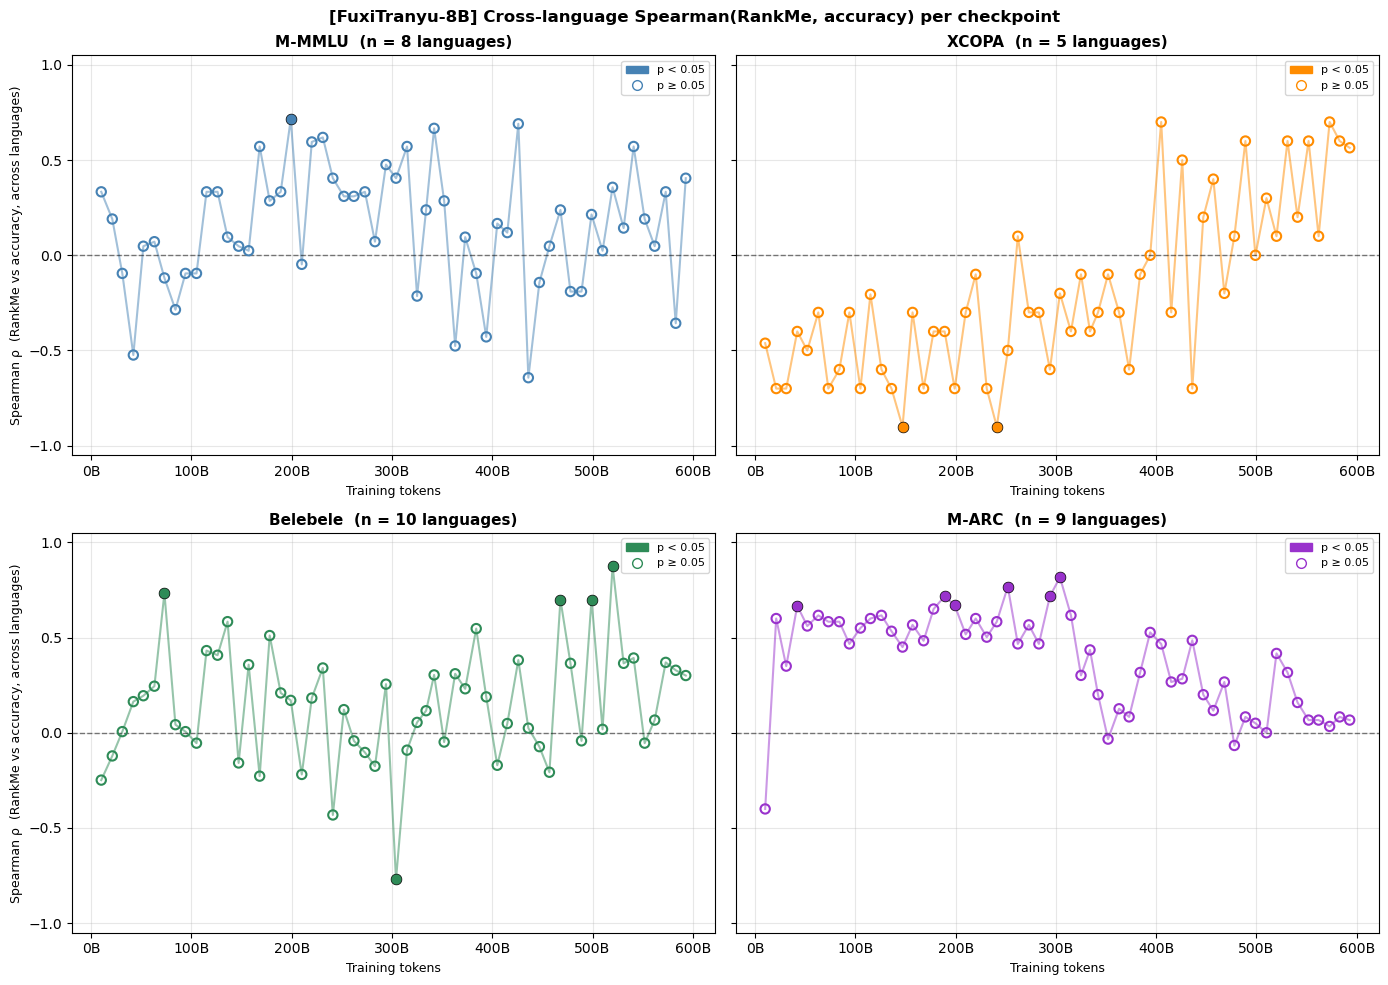

Saved: plots_joao_pinto_407597/rankme_checkpoint_correlations_fuxi.png


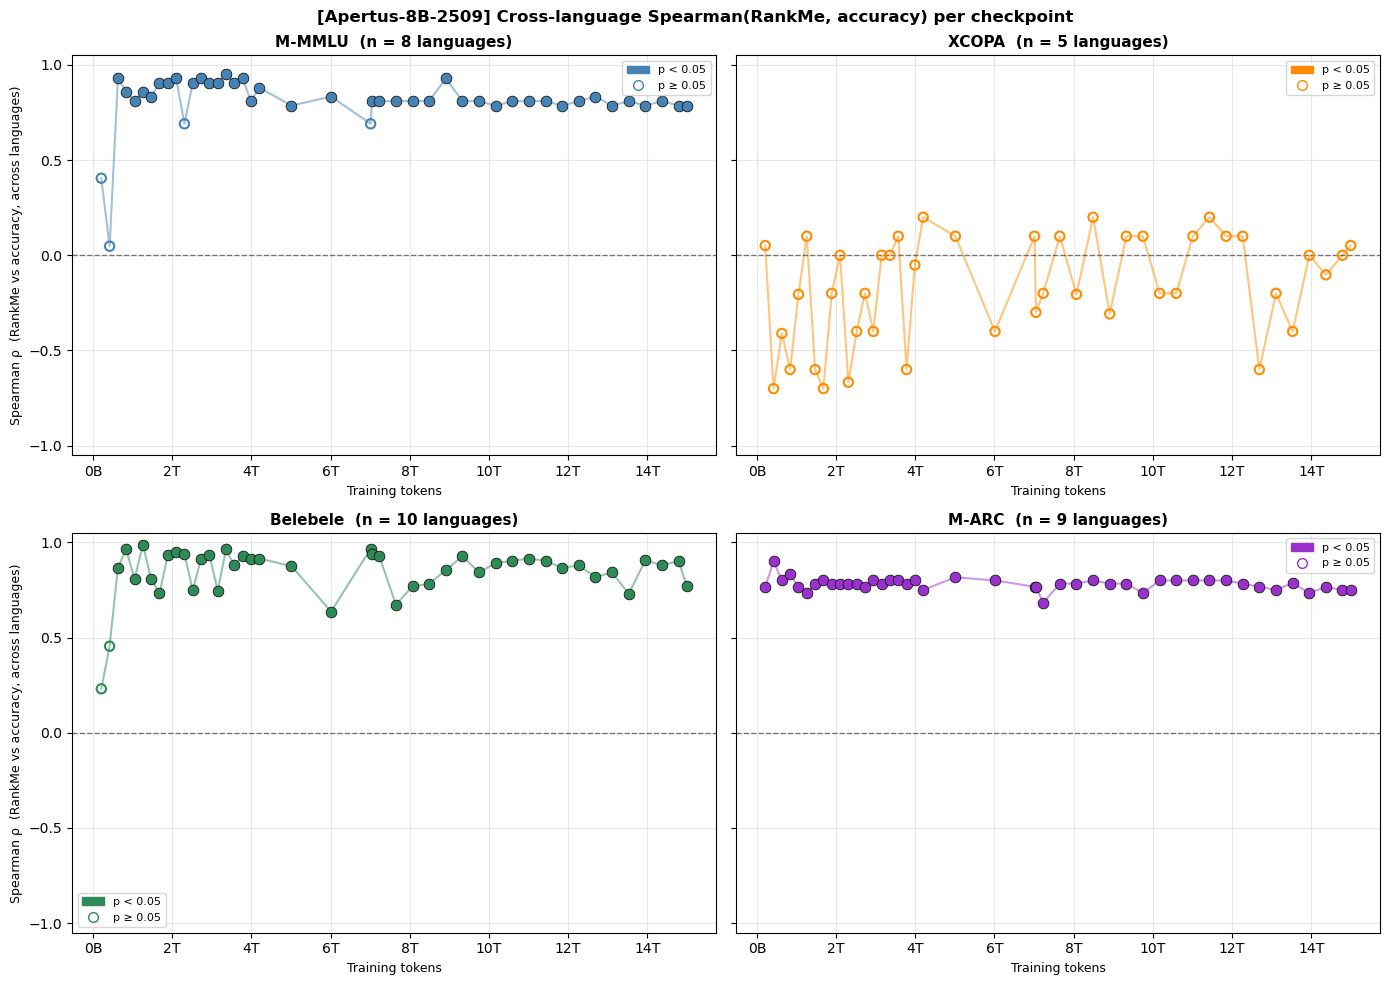

Saved: plots_joao_pinto_407597/rankme_checkpoint_correlations_apertus.png


In [ ]:
show_checkpoint_correlations(MODELS, data)

## Per-Checkpoint Correlation Findings

### FuxiTranyu-8B

**m-MMLU (8 languages): 1/57 checkpoints significant, max ρ = 0.714**

Near-zero correlation throughout training, as expected. All 8 languages stay at random chance (~25%), leaving essentially no accuracy variance to correlate with RankMe. The 1 significant checkpoint is noise.

**XCOPA (5 languages): 2/57 checkpoints significant, min ρ = −0.900**

Two significant checkpoints, both with negative ρ. The minimum ρ = −0.900 is striking: at those two points in training, the cross-language RankMe ranking at layer 21 is strongly *inversely* correlated with XCOPA accuracy. This inversion is driven by language-level differences: Vietnamese has the lowest RankMe at the first checkpoint (135) among the XCOPA languages, yet achieves the best peak XCOPA accuracy (0.736) and earliest grokking onset (126B); Chinese and Turkish have higher RankMe but worse XCOPA outcomes. This suggests that XCOPA performance is *negatively* associated with representational richness at layer 21 — unlike every other benchmark where the relationship is positive. However, with only 2 out of 57 checkpoints reaching significance, this result should be interpreted with caution: the evidence is suggestive but not conclusive.

**Belebele (10 languages): 5/57 checkpoints significant, max ρ = 0.875**

With all 10 languages near random chance (peak accuracy range 0.296–0.317), cross-language accuracy variance is negligible. The few significant checkpoints are isolated and do not reflect a sustained pattern. The geometry has no reliable predictive power for Belebele in FuxiTranyu-8B.

**M-ARC (9 languages): 6/57 checkpoints significant, max ρ = 0.817**

The strongest per-checkpoint result for FuxiTranyu-8B: 6 significant checkpoints, peaking at ρ = 0.817. This is consistent with the static predictor analysis, where RankMe at first checkpoint is a significant Pearson predictor of peak M-ARC accuracy (Pe r = +0.816, p = 0.007). However, the alignment is not sustained across training (only 6/57 checkpoints reach significance).

---

### Apertus-8B-2509

**m-MMLU (8 languages): 40/44 checkpoints significant, max ρ = 0.952**

Throughout 91% of training, the language ranking by RankMe at layer 19 is significantly correlated with the language ranking by m-MMLU accuracy at that same checkpoint (max ρ = 0.952). The geometry is thus predictive not only retrospectively from the final trajectory — as shown in the predictor analysis above — but also at each individual checkpoint throughout training.

**XCOPA (5 languages): 0/44 checkpoints significant, max ρ = 0.200**

No significant correlation at any checkpoint. XCOPA peak accuracies are tightly clustered (0.702–0.784) and established early — 3 of 5 languages grokk by 210B tokens — with accuracy remaining stable thereafter. Since cross-language accuracy variance stays low and flat throughout most of training, there is no signal for the per-checkpoint correlation to detect. This is consistent with the predictor analysis, where no static predictor reached significance for XCOPA in Apertus.

**Belebele (10 languages): 42/44 checkpoints significant, max ρ = 0.988**

The highest peak per-checkpoint correlation in the notebook: 95% of checkpoints reach significance, maximum ρ = 0.988. With 10 languages spanning a wide peak accuracy range (0.661–0.841), there is rich cross-language signal once languages start differentiating. The 2 non-significant checkpoints are the very earliest (210B and 420B), before any language has crossed the grokking threshold (all languages grokk between 630B and 2 100B).

**M-ARC (9 languages): 44/44 checkpoints significant, max ρ = 0.900**

The most consistent result in the notebook: every single checkpoint reaches significance (100%). Even at the very first checkpoint (210B), when only English has grokked and the remaining 7 languages (Hindi never grokks) are still below the threshold, the RankMe ranking already predicts the M-ARC accuracy ordering. The maximum ρ = 0.900 is slightly below Belebele's peak, but the perfect consistency across all checkpoints is unique to M-ARC.

---

### Cross-model summary

**M-ARC is the only benchmark where the per-checkpoint geometry is predictive in both models** — 6/57 significant checkpoints for FuxiTranyu-8B and 44/44 for Apertus-8B-2509. This replicates the cross-model finding from the predictor analysis, where early-training richness was the only static predictor of peak M-ARC accuracy reaching significance in both models. For all other benchmarks, the per-checkpoint signal either does not exist in Fuxi (m-MMLU, Belebele) or is only weakly present and potentially inverted (XCOPA).

---

### 💡 Key findings

- **Both models — M-ARC:** the only benchmark with significant per-checkpoint geometry–accuracy correlation in both models, though to very different degrees (6/57 vs 44/44). Replicates the cross-model pattern from the predictor analysis.
- **Apertus — m-MMLU and Belebele:** RankMe at layer 19 tracks the cross-language accuracy ranking throughout 91% and 95% of training respectively — the geometry predicts which languages perform best at each individual checkpoint, not only from the final trajectory.
- **Both models — XCOPA:** no reliable per-checkpoint correlation. For Fuxi, 2 checkpoints show a negative ρ (inverse direction), but the evidence is too sparse to draw firm conclusions.
- **Fuxi — m-MMLU and Belebele:** no per-checkpoint signal; accuracy stays near random chance throughout training, leaving no cross-language variance to detect.